In [1]:
from engine_api.math_service.math_model.tsp_runner import KCycleTSPRunner
from engine_api.math_service.math_model.tsp_config import *

In [2]:
runner = KCycleTSPRunner()

runner.load_data(
    DATA_SOURCE=DATA_SOURCE,
    EXCEL_PATH=EXCEL_PATH,
    TSPLIB_PATH=TSPLIB_PATH,
    s_value=s_value,
    k_value=k_value
)

runner.build_model(
    CONNECTIVITY=CONNECTIVITY,
    group_size=group_size,
    speed_kmph=speed_kmph,
    route_pace=route_pace
)

WARNING (W1002): Setting Var 'u[1]' to a numeric value `0` outside the bounds
(1, 5).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002

Problem: 
- Lower bound: -.inf
  Upper bound: .inf
  Number of objectives: 1
  Number of constraints: 0
  Number of variables: 199
  Sense: unknown
Solver: 
- Status: ok
  Message: CPLEX 22.1.2\x3a optimal solution; objective 86.79; 622 simplex iterations
  Termination condition: optimal
  Id: 0
Solution: 
- number of solutions: 0
  number of solutions displayed: 0

Objective = 86.78999999999999
Total distance = 86.78999999999999 km
Total budget   = 12440.0 UAH
Total time     = 554.148 minutes
Tour: [1, 4, 7, 3, 5, 6, 1]


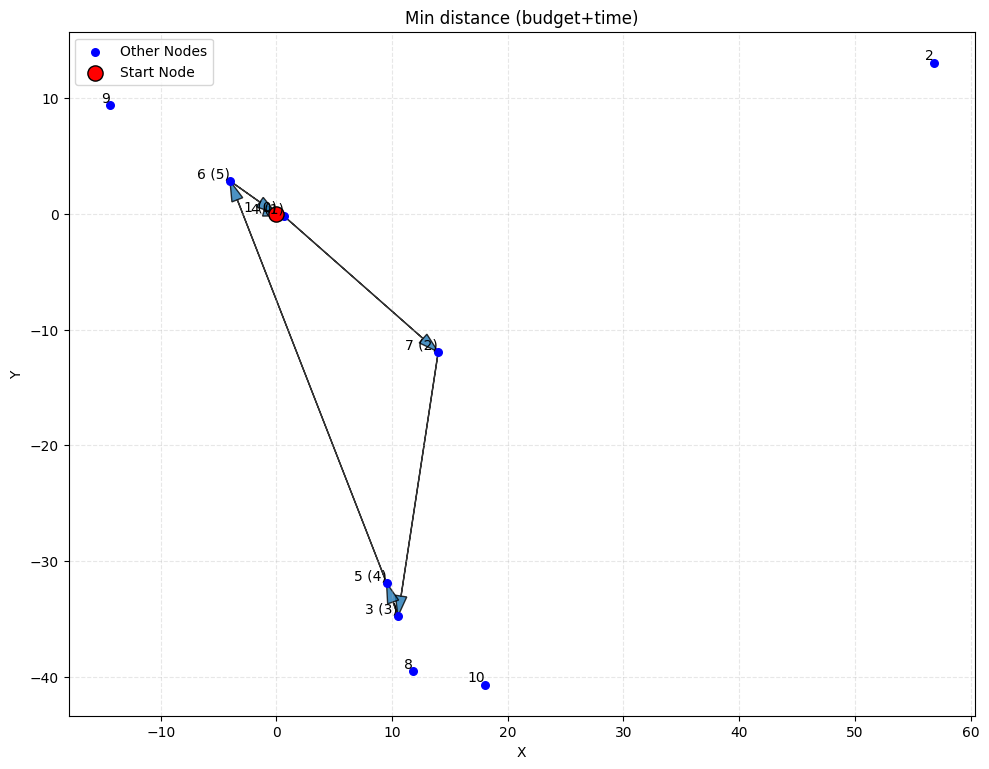

In [3]:
runner.apply_min_distance(budget_max=budget_max, time_max=time_max)

results, ok = runner.solve(SOLVER=SOLVER, NEOS_EMAIL=NEOS_EMAIL, tee=False)

if ok:
    runner.print_metrics()
    runner.extract_tour()
    print("Tour:", runner.tour)
    runner.plot(title="Min distance (budget+time)")
else:
    print("Cannot construct tour with provided constraints")
    print(f"Check your limits:\n - Budget: {budget_max} UAH\n - Time: {time_max:.1f} Hours\n - Number of places: {k_value}")
    print("Try increasing your budget/time or reducing the number of points.")

'pyomo.core.base.objective.ScalarObjective'>) on block unknown with a new
Component (type=<class 'pyomo.core.base.objective.AbstractScalarObjective'>).
This is usually indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().

Problem: 
- Lower bound: -.inf
  Upper bound: .inf
  Number of objectives: 1
  Number of constraints: 0
  Number of variables: 199
  Sense: unknown
Solver: 
- Status: ok
  Message: CPLEX 22.1.2\x3a optimal solution; objective 7140; 1 simplex iterations
  Termination condition: optimal
  Id: 0
Solution: 
- number of solutions: 0
  number of solutions displayed: 0

Objective = 7140.0
Total distance = 176.99 km
Total budget   = 7140.0 UAH
Total time     = 662.3879999999999 minutes
Tour: [1, 7, 8, 4, 10, 3, 1]


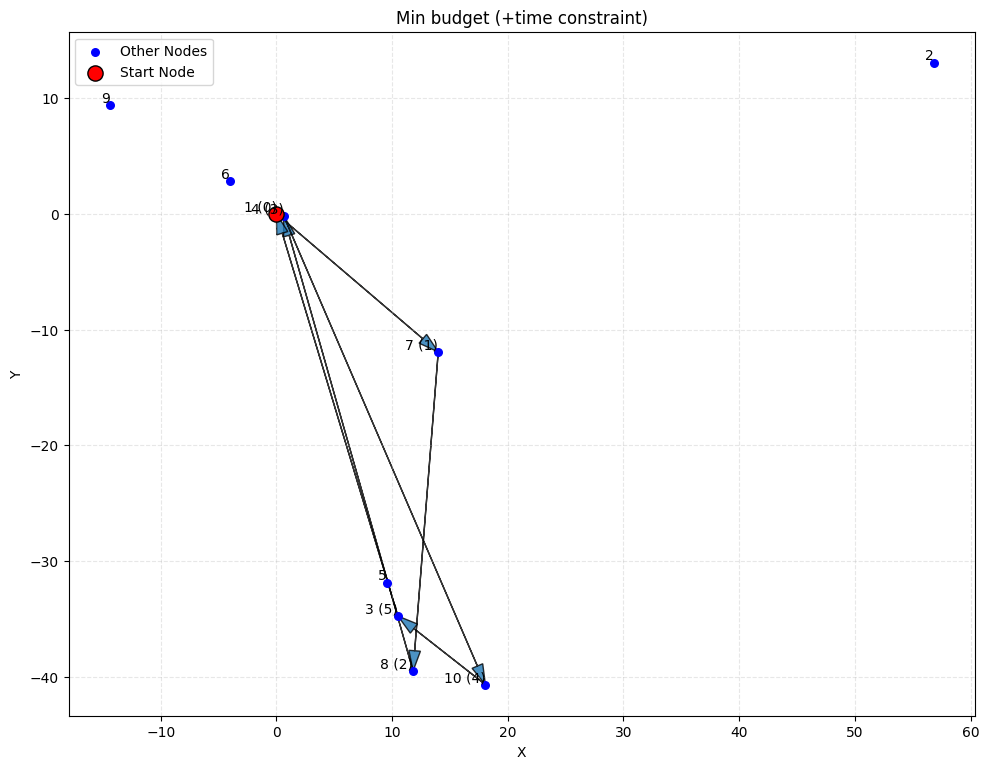

In [5]:
runner.apply_min_budget(time_max=time_max, dist_max=dist_max)

results, ok = runner.solve(SOLVER=SOLVER, NEOS_EMAIL=NEOS_EMAIL, tee=False)

if ok:
    runner.print_metrics()
    runner.extract_tour()
    print("Tour:", runner.tour)
    runner.plot(title="Min budget (+time constraint)")
else:
    print("Cannot construct tour with provided constraints")
    print(f"Check your limits:\n - Budget: {budget_max} UAH\n - Time: {time_max:.1f} Hours\n - Number of places: {k_value}")
    print("Try increasing your budget/time or reducing the number of points.")

'pyomo.core.base.objective.ScalarObjective'>) on block unknown with a new
Component (type=<class 'pyomo.core.base.objective.AbstractScalarObjective'>).
This is usually indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().

Problem: 
- Lower bound: -.inf
  Upper bound: .inf
  Number of objectives: 1
  Number of constraints: 0
  Number of variables: 199
  Sense: unknown
Solver: 
- Status: ok
  Message: CPLEX 22.1.2\x3a optimal solution; objective 554.148; 276 simplex iterations; absmipgap=1.13687e-13, relmipgap=0
  Termination condition: optimal
  Id: 0
Solution: 
- number of solutions: 0
  number of solutions displayed: 0

Objective = 554.148
Total distance = 86.79 km
Total budget   = 12440.0 UAH
Total time     = 554.148 minutes
Tour: [1, 6, 5, 3, 7, 4, 1]


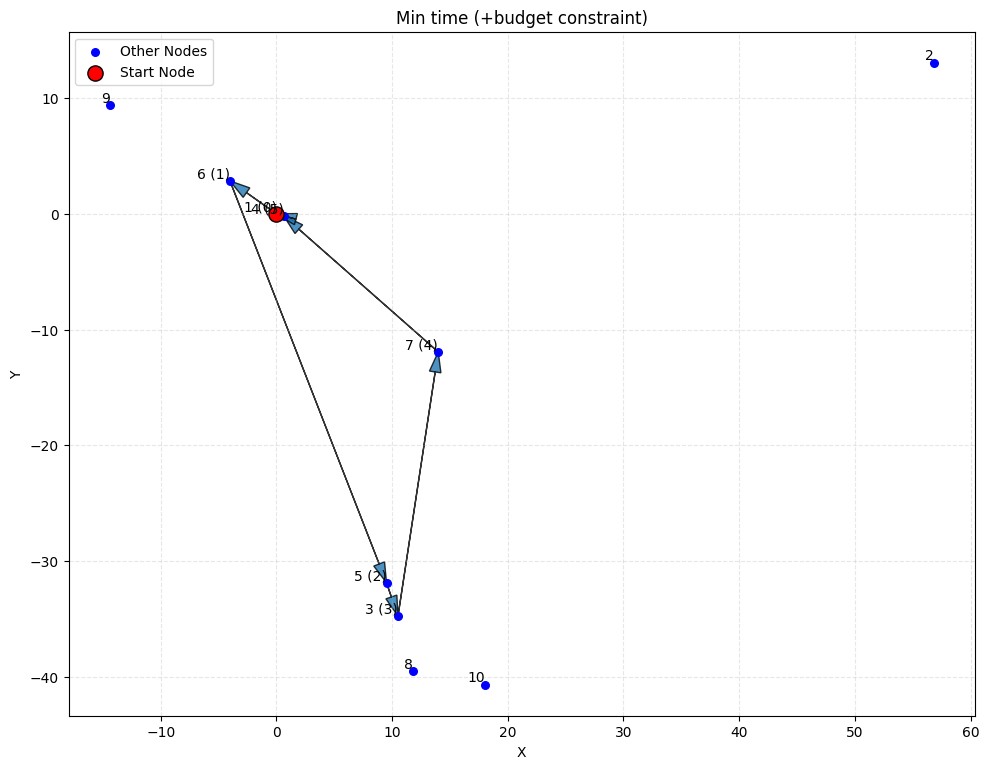

In [7]:
runner.apply_min_time(budget_max=budget_max, dist_max=dist_max)

results, ok = runner.solve(SOLVER=SOLVER, NEOS_EMAIL=NEOS_EMAIL, tee=False)

if ok:
    runner.print_metrics()
    runner.extract_tour()
    print("Tour:", runner.tour)
    runner.plot(title="Min time (+budget constraint)")
else:
    print("Cannot construct tour with provided constraints")
    print(f"Check your limits:\n - Budget: {budget_max} UAH\n - Time: {time_max:.1f} Hours\n - Number of places: {k_value}")
    print("Try increasing your budget/time or reducing the number of points.")